Pipeline  : 2000-01-01  →  2026-03-31
[Data] (6418, 8)  |  2000-08-30 → 2026-03-30
[Features] shape=(6418, 93)
[Regime] rows=6397  features=5
[Regime] cov='diag'  score=-36295.42
[Regime] dist:
 Market_Regime
0    3053
1    2081
2    1284
Name: count, dtype: int64


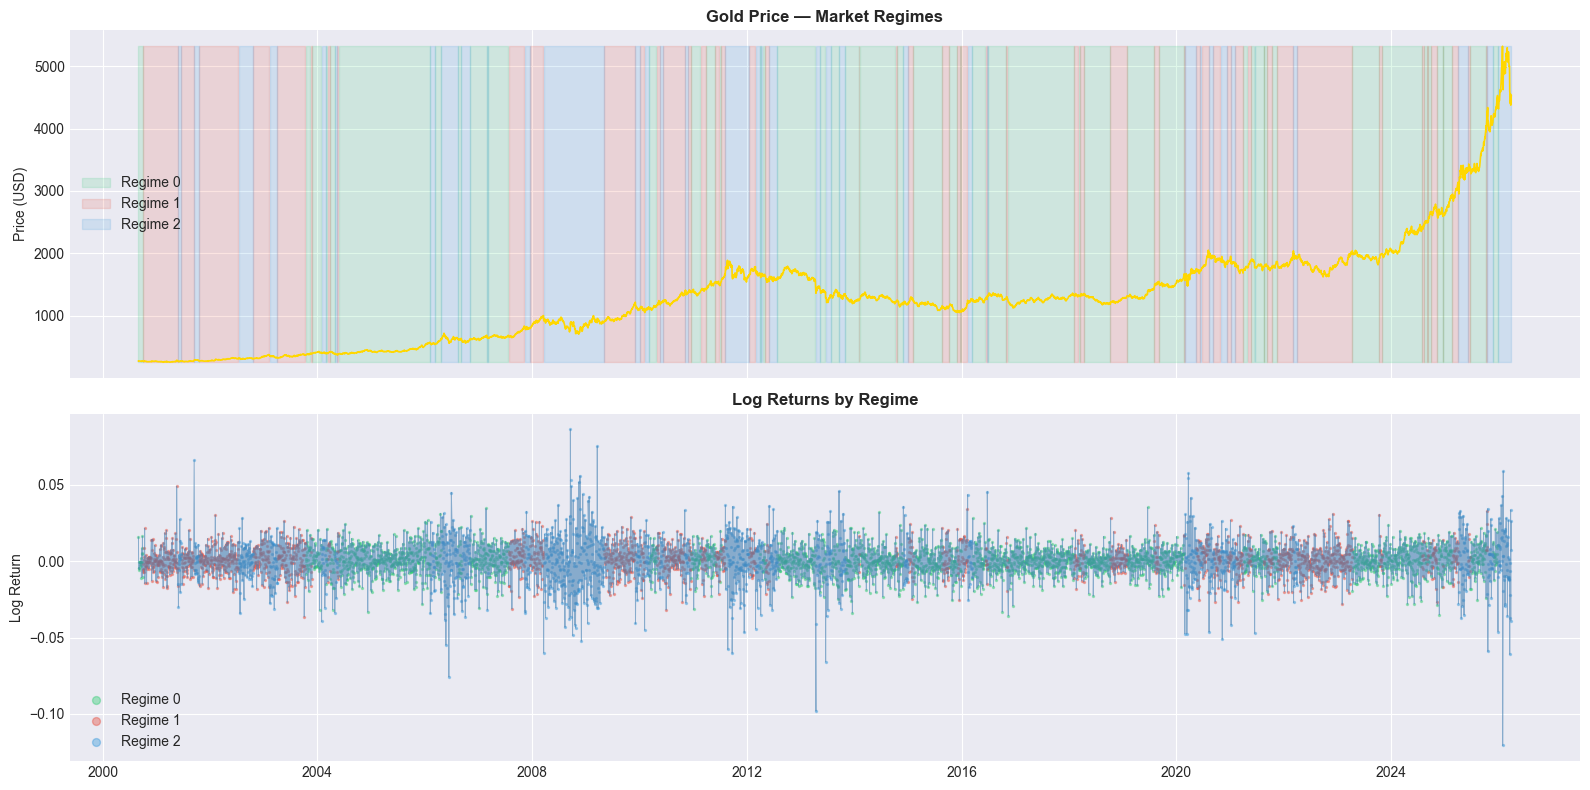

[Clean] (6217, 97)  features=93


In [21]:
# ============================================================
# GOLD PRICE PREDICTION — FULL PIPELINE
# ============================================================

# ── INSTALL ──────────────────────────────────────────────────
# pip install yfinance pandas numpy scikit-learn ta tensorflow
# pip install PyWavelets hmmlearn matplotlib seaborn requests

# ============================================================
# 0. IMPORTS
# ============================================================
import warnings, os
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.dates     as mdates
import pywt
import yfinance             as yf
import requests
import tensorflow           as tf

from datetime               import date
from hmmlearn.hmm           import GaussianHMM
from sklearn.preprocessing  import StandardScaler
from sklearn.metrics        import (mean_squared_error,
                                    mean_absolute_error, r2_score)
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble       import RandomForestRegressor
from sklearn.cluster        import KMeans
import ta

from tensorflow.keras.models     import Model, Sequential
from tensorflow.keras.layers     import (
    LSTM, GRU, Dense, Dropout, Conv1D, MaxPooling1D,
    Bidirectional, Input, MultiHeadAttention,
    LayerNormalization, BatchNormalization, Add
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks  import (
    EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint, LearningRateScheduler
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# 1. GLOBAL CONFIG
# ============================================================
START_DATE  = "2000-01-01"
#END_DATE    = date.today().strftime("%Y-%m-%d")
END_DATE="2026-03-31"
LOOKBACK    = 60
HORIZON     = 1
TRAIN_FRAC  = 0.70
VAL_FRAC    = 0.15
EPOCHS      = 150
BATCH_SIZE  = 32
TOP_K       = 40

print(f"Pipeline  : {START_DATE}  →  {END_DATE}")

# ============================================================
# 2. DATA DOWNLOAD  (yfinance MultiIndex safe)
# ============================================================
def fetch_ticker(ticker, col='Close', rename=None):
    raw = yf.download(ticker, start=START_DATE, end=END_DATE,
                      auto_adjust=True, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = ['_'.join(c).strip() for c in raw.columns]
        matched = [c for c in raw.columns if col in c]
        if not matched:
            raise KeyError(f"'{col}' not found in {raw.columns.tolist()}")
        raw = raw[[matched[0]]].rename(
            columns={matched[0]: rename or matched[0]})
    else:
        raw = raw[[col]].rename(columns={col: rename or col})
    return raw

def download_data():
    gold     = fetch_ticker("GC=F",     'Close',  'Gold_Close')
    usd      = fetch_ticker("DX-Y.NYB", 'Close',  'USD_Index')
    sp500_c  = fetch_ticker("^GSPC",    'Close',  'SP500')
    sp500_v  = fetch_ticker("^GSPC",    'Volume', 'SP500_Volume')
    vix      = fetch_ticker("^VIX",     'Close',  'VIX')
    silver   = fetch_ticker("SI=F",     'Close',  'Silver')
    oil      = fetch_ticker("CL=F",     'Close',  'Oil_WTI')
    treasury = fetch_ticker("^TNX",     'Close',  'Treasury_10Y')

    sp500 = sp500_c.join(sp500_v, how='left')
    df    = gold.copy()
    for frame in [usd, sp500, vix, silver, oil, treasury]:
        df = df.join(frame, how='left')

    df.dropna(subset=['Gold_Close'], inplace=True)
    df.ffill(inplace=True)
    df.bfill(inplace=True)
    print(f"[Data] {df.shape}  |  "
          f"{df.index[0].date()} → {df.index[-1].date()}")
    return df

df = download_data()

# ============================================================
# 3. FED FUNDS RATE (FRED)
# ============================================================
def fetch_fed_rate(df_index):
    url = ("https://fred.stlouisfed.org/graph/fredgraph.csv"
           "?id=FEDFUNDS")
    try:
        fed = pd.read_csv(url, index_col=0, parse_dates=True)
        fed.columns = ['Fed_Rate']
        return fed[fed.index >= START_DATE].resample('B').ffill()
    except Exception as e:
        print(f"[FRED] failed ({e}) → using 0.")
        return pd.DataFrame({'Fed_Rate': 0.0}, index=df_index)

df = df.join(fetch_fed_rate(df.index), how='left')
df['Fed_Rate'].ffill(inplace=True)
df['Fed_Rate'].fillna(0.0, inplace=True)

# ============================================================
# 4. WAVELET DENOISING
# ============================================================
def wavelet_denoise(series: np.ndarray,
                    wavelet='db4', level=3) -> np.ndarray:
    coeffs = pywt.wavedec(series, wavelet, level=level)
    sigma  = np.median(np.abs(coeffs[-1])) / 0.6745
    thresh = sigma * np.sqrt(2 * np.log(len(series)))
    coeffs[1:] = [pywt.threshold(c, thresh, mode='soft')
                  for c in coeffs[1:]]
    return pywt.waverec(coeffs, wavelet)[:len(series)]

df['Gold_Close_Denoised'] = wavelet_denoise(df['Gold_Close'].values)
df['Gold_LR_Denoised']    = np.log(
    df['Gold_Close_Denoised'] /
    pd.Series(df['Gold_Close_Denoised'],
              index=df.index).shift(1).values
)

# ============================================================
# 5. LOG RETURN (TARGET)
# ============================================================
df['Gold_Log_Return'] = np.log(
    df['Gold_Close'] / df['Gold_Close'].shift(1))

# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    gc = df['Gold_Close']
    lr = df['Gold_Log_Return']

    # ── Technical Indicators ─────────────────────────────────
    df['RSI_14'] = ta.momentum.RSIIndicator(gc, 14).rsi()
    df['RSI_7']  = ta.momentum.RSIIndicator(gc, 7).rsi()

    macd = ta.trend.MACD(gc)
    df['MACD']        = macd.macd()
    df['MACD_Signal'] = macd.macd_signal()
    df['MACD_Diff']   = macd.macd_diff()

    for w in [9, 21, 50, 100, 200]:
        df[f'EMA_{w}'] = ta.trend.EMAIndicator(gc, w).ema_indicator()
    for w in [10, 20, 50, 200]:
        df[f'SMA_{w}'] = ta.trend.SMAIndicator(gc, w).sma_indicator()

    bb = ta.volatility.BollingerBands(gc, 20, 2)
    df['BB_High']  = bb.bollinger_hband()
    df['BB_Low']   = bb.bollinger_lband()
    df['BB_Width'] = bb.bollinger_wband()
    df['BB_Pct']   = bb.bollinger_pband()
    df['ATR_14']   = gc.rolling(14).std()

    stoch = ta.momentum.StochasticOscillator(gc, gc, gc, 14, 3)
    df['Stoch_K']   = stoch.stoch()
    df['Stoch_D']   = stoch.stoch_signal()
    df['WilliamsR'] = ta.momentum.WilliamsRIndicator(
                          gc, gc, gc, 14).williams_r()
    df['CCI_20']    = ta.trend.CCIIndicator(gc, gc, gc, 20).cci()

    adx = ta.trend.ADXIndicator(gc, gc, gc, 14)
    df['ADX']     = adx.adx()
    df['ADX_Pos'] = adx.adx_pos()
    df['ADX_Neg'] = adx.adx_neg()

    if 'SP500_Volume' in df.columns:
        df['MFI_14'] = ta.volume.MFIIndicator(
            gc, gc, gc, df['SP500_Volume'], 14).money_flow_index()

    # ── Volatility ───────────────────────────────────────────
    for w in [5, 21, 63]:
        df[f'Gold_Vol_{w}']  = lr.rolling(w).std()
        df[f'Gold_RVar_{w}'] = lr.rolling(w).var()

    # ── Lag Returns ──────────────────────────────────────────
    for lag in [1, 2, 3, 5, 10, 21]:
        df[f'LR_Lag_{lag}'] = lr.shift(lag)

    # ── Momentum ─────────────────────────────────────────────
    for w in [5, 10, 21, 63]:
        df[f'Mom_{w}'] = gc / gc.shift(w) - 1

    # ── Price Position ───────────────────────────────────────
    df['P_vs_SMA50']  = gc / df['SMA_50']  - 1
    df['P_vs_SMA200'] = gc / df['SMA_200'] - 1
    df['EMA9_EMA21']  = df['EMA_9'] / df['EMA_21'] - 1

    # ── Donchian Channel ─────────────────────────────────────
    df['Don_High'] = gc.rolling(20).max()
    df['Don_Low']  = gc.rolling(20).min()
    df['Don_Pct']  = ((gc - df['Don_Low']) /
                      (df['Don_High'] - df['Don_Low'] + 1e-9))

    # ── Z-Score ──────────────────────────────────────────────
    for w in [20, 60]:
        df[f'ZScore_{w}'] = ((gc - gc.rolling(w).mean()) /
                              gc.rolling(w).std())

    # ── Autocorrelation ──────────────────────────────────────
    for lag in [1, 5, 10]:
        df[f'AutoCorr_{lag}'] = lr.rolling(30).apply(
            lambda x: pd.Series(x).autocorr(lag=lag), raw=False)

    # ── Hurst Exponent ───────────────────────────────────────
    def hurst(ts, max_lag=20):
        lags = range(2, max_lag)
        tau  = [np.std(np.subtract(ts[l:], ts[:-l])) for l in lags]
        poly = np.polyfit(np.log(list(lags)), np.log(tau), 1)
        return poly[0]

    df['Hurst'] = [
        hurst(gc.iloc[max(0, i-60):i+1].values)
        if i >= 60 else np.nan
        for i in range(len(gc))
    ]

    # ── Macro / Cross-Asset ──────────────────────────────────
    df['USD_Return']      = np.log(df['USD_Index'] /
                                   df['USD_Index'].shift(1))
    df['USD_Return_5d']   = np.log(df['USD_Index'] /
                                   df['USD_Index'].shift(5))
    df['Gold_Silver']     = gc / df['Silver']
    df['Oil_Return']      = np.log(df['Oil_WTI'] /
                                   df['Oil_WTI'].shift(1))
    df['SP500_Return']    = np.log(df['SP500'] / df['SP500'].shift(1))
    df['Treasury_Change'] = df['Treasury_10Y'].diff()
    df['Fed_Rate_Change'] = df['Fed_Rate'].diff()
    df['VIX_Change']      = df['VIX'].diff()
    df['VIX_Z']           = ((df['VIX'] - df['VIX'].rolling(63).mean()) /
                              df['VIX'].rolling(63).std())
    df['Real_Rate']       = (df['Treasury_10Y'] -
                              df['Gold_Vol_21'] * 100)
    df['Gold_USD_Mom']    = (lr.rolling(10).sum() -
                              df['USD_Return'].rolling(10).sum())

    if 'SP500_Volume' in df.columns:
        df['VPT']        = (lr * df['SP500_Volume']).cumsum()
        df['VPT_Signal'] = df['VPT'].rolling(14).mean()
        df['OI_Ratio']   = (df['SP500_Volume'] /
                            df['SP500_Volume'].rolling(20).mean())

    # ── Sentiment ────────────────────────────────────────────
    df['Fear_Greed']   = (
        -df['VIX_Z'] * 0.4 +
         df['RSI_14'].fillna(50) / 100 * 0.3 +
         df['SP500_Return'].rolling(5).sum() * 0.3
    )
    df['Sentiment_MA5'] = df['Fear_Greed'].rolling(5).mean()

    # ── Calendar ─────────────────────────────────────────────
    df['Month_sin']  = np.sin(2 * np.pi * df.index.month / 12)
    df['Month_cos']  = np.cos(2 * np.pi * df.index.month / 12)
    df['DOW_sin']    = np.sin(2 * np.pi * df.index.dayofweek / 5)
    df['DOW_cos']    = np.cos(2 * np.pi * df.index.dayofweek / 5)
    df['IsMonthEnd'] = df.index.is_month_end.astype(int)
    df['IsQtrEnd']   = df.index.is_quarter_end.astype(int)
    df['Monthly_Seas'] = df.groupby(
        df.index.month)['Gold_Log_Return'].transform('mean')

    # ── Denoised LR lags ─────────────────────────────────────
    for lag in [1, 3, 5]:
        df[f'LR_Den_Lag_{lag}'] = df['Gold_LR_Denoised'].shift(lag)

    return df

df = engineer_features(df)
print(f"[Features] shape={df.shape}")

# ============================================================
# 7. MARKET REGIME —  (covariance + K-Means)
# ============================================================
def add_market_regime(df, n_regimes=3):
    regime_feats = ['Gold_Log_Return', 'Gold_Vol_21']
    for f in ['RSI_14', 'VIX', 'USD_Return']:
        if f in df.columns:
            regime_feats.append(f)

    sub        = df[regime_feats].dropna().copy()
    rs         = StandardScaler()
    sub_scaled = rs.fit_transform(sub.values)
    mask       = np.all(np.isfinite(sub_scaled), axis=1)
    sub_clean  = sub_scaled[mask]
    idx_clean  = sub.index[mask]

    print(f"[Regime] rows={sub_clean.shape[0]}  "
          f"features={sub_clean.shape[1]}")

    best_model, best_score, best_cov = None, -np.inf, None

    for cov_type in ['diag', 'tied', 'spherical']:
        for attempt in range(5):
            try:
                hmm = GaussianHMM(
                    n_components    = n_regimes,
                    covariance_type = cov_type,
                    n_iter          = 300,
                    tol             = 1e-4,
                    random_state    = SEED + attempt,
                    init_params     = 'stmc',
                    params          = 'stmc',
                )
                hmm.fit(sub_clean)
                score = hmm.score(sub_clean)
                if score > best_score:
                    best_score = score
                    best_model = hmm
                    best_cov   = cov_type
            except Exception:
                continue

    if best_model is None:
        print("[Regime] HMM failed → K-Means fallback")
        km     = KMeans(n_clusters=n_regimes,
                        random_state=SEED, n_init=10)
        labels = km.fit_predict(sub_clean)
    else:
        labels = best_model.predict(sub_clean)
        print(f"[Regime] cov='{best_cov}'  score={best_score:.2f}")

    regime_s = pd.Series(labels, index=idx_clean,
                          name='Market_Regime')
    df = df.join(regime_s)
    df['Market_Regime'].fillna(
        df['Market_Regime'].mode()[0], inplace=True)
    df['Market_Regime'] = df['Market_Regime'].astype(int)

    for r in range(n_regimes):
        df[f'Regime_{r}'] = (df['Market_Regime'] == r).astype(int)

    print("[Regime] dist:\n", df['Market_Regime'].value_counts())

    # Plot regimes
    colors = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6']
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    axes[0].plot(df.index, df['Gold_Close'],
                 color='gold', lw=1.2)
    axes[0].set_title('Gold Price — Market Regimes',
                      fontweight='bold')
    axes[0].set_ylabel('Price (USD)')
    for r in range(n_regimes):
        m_r = df['Market_Regime'] == r
        axes[0].fill_between(
            df.index,
            df['Gold_Close'].min(), df['Gold_Close'].max(),
            where=m_r, alpha=0.15,
            color=colors[r % len(colors)],
            label=f'Regime {r}')
    axes[0].legend()

    axes[1].plot(df.index, df['Gold_Log_Return'],
                 color='steelblue', lw=0.7, alpha=0.6)
    for r in range(n_regimes):
        m_r = df['Market_Regime'] == r
        axes[1].scatter(df.index[m_r],
                        df['Gold_Log_Return'][m_r],
                        s=2, alpha=0.4,
                        color=colors[r % len(colors)],
                        label=f'Regime {r}')
    axes[1].set_title('Log Returns by Regime', fontweight='bold')
    axes[1].set_ylabel('Log Return')
    axes[1].legend(markerscale=4)
    plt.tight_layout()
    plt.savefig('00_regimes.png', dpi=150)
    plt.show()
    return df

df = add_market_regime(df)

# ============================================================
# 8. CLEAN
# ============================================================
TARGET       = 'Gold_Log_Return'
EXCLUDE      = ['Gold_Close', 'Gold_Close_Denoised', 'Market_Regime']
feature_cols = [c for c in df.columns
                if c not in EXCLUDE + [TARGET]]

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print(f"[Clean] {df.shape}  features={len(feature_cols)}")

X_raw = df[feature_cols].values
y_raw = df[TARGET].values

# ============================================================
# 9. SCALING
# ============================================================
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(
    y_raw.reshape(-1, 1)).flatten()


In [23]:
# ============================================================
# 10. FEATURE SELECTION
# ============================================================
N_SPLIT = int(len(X_scaled) * TRAIN_FRAC)

def select_top_features(X_2d, y, cols, top_k=TOP_K):
    mi   = mutual_info_regression(X_2d, y, random_state=SEED)
    rf   = RandomForestRegressor(100, n_jobs=-1, random_state=SEED)
    rf.fit(X_2d, y)
    mi_r = pd.Series(mi, index=cols).rank(ascending=False)
    rf_r = pd.Series(rf.feature_importances_,
                     index=cols).rank(ascending=False)
    top  = (mi_r + rf_r).sort_values().head(top_k).index.tolist()
    print(f"[FeatSel] top {top_k}: {top[:8]} ...")
    return top

top_features = select_top_features(
    X_scaled[:N_SPLIT], y_scaled[:N_SPLIT], feature_cols)
top_idx      = [feature_cols.index(f) for f in top_features]
X_sel        = X_scaled[:, top_idx]
N_FEATURES   = len(top_features)

# ============================================================
# 11. SEQUENCES
# ============================================================
def make_sequences(X, y, lookback=LOOKBACK, horizon=HORIZON):
    Xs, ys = [], []
    for i in range(lookback, len(X) - horizon + 1):
        Xs.append(X[i - lookback:i])
        ys.append(y[i + horizon - 1])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_sel, y_scaled)
print(f"[Seq] X={X_seq.shape}  y={y_seq.shape}")

n       = len(X_seq)
n_train = int(n * TRAIN_FRAC)
n_val   = int(n * VAL_FRAC)

X_train, y_train = X_seq[:n_train],               y_seq[:n_train]
X_val,   y_val   = X_seq[n_train:n_train+n_val],  y_seq[n_train:n_train+n_val]
X_test,  y_test  = X_seq[n_train+n_val:],         y_seq[n_train+n_val:]
print(f"[Split] Train={X_train.shape} Val={X_val.shape} "
      f"Test={X_test.shape}")

# ============================================================
# 12. MODEL ARCHITECTURES  (all LayerNormalization FIXED)
# ============================================================

# ── A: TFT-Lite ──────────────────────────────────────────────
def build_tft_lite():
    inp = Input(shape=(LOOKBACK, N_FEATURES))
    x   = Dense(128, activation='elu')(inp)
    x   = Dropout(0.1)(x)
    a   = MultiHeadAttention(
              num_heads=8, key_dim=16, dropout=0.1)(x, x)
    
    x   = LayerNormalization(epsilon=1e-6)(x + a)
    ff  = Dense(256, activation='elu')(x)
    ff  = Dense(128)(ff)
    ff  = Dropout(0.1)(ff)
    x   = LayerNormalization(epsilon=1e-6)(x + ff)   
    x   = LSTM(64, return_sequences=True)(x)
    x   = LSTM(32)(x)
    x   = Dense(64, activation='elu')(x)
    x   = Dropout(0.2)(x)
    out = Dense(1)(x)
    m   = Model(inp, out)
    m.compile(Adam(1e-3, clipnorm=1.0),
              loss='huber', metrics=['mae'])
    return m




# ── B: Residual LSTM ─────────────────────────────────────────
def build_residual_lstm():
    inp  = Input(shape=(LOOKBACK, N_FEATURES))
    x    = Conv1D(64, 3, padding='causal', activation='relu')(inp)
    x    = BatchNormalization()(x)
    out1 = LSTM(128, return_sequences=True)(x)
    out1 = Dropout(0.2)(out1)
    s1   = Conv1D(128, 1)(x)
    x    = Add()([out1, s1])
    x    = LayerNormalization(epsilon=1e-6)(x)
    out2 = LSTM(128, return_sequences=True)(x)
    out2 = Dropout(0.2)(out2)
    x    = Add()([out2, x])
    x    = LayerNormalization(epsilon=1e-6)(x)
    x    = LSTM(64)(x)
    x    = Dense(32, activation='relu',
                 kernel_regularizer=l2(1e-4))(x)   # l2 is now the regularizer again
    out  = Dense(1)(x)
    m    = Model(inp, out)
    m.compile(Adam(5e-4, clipnorm=1.0),
              loss='huber', metrics=['mae'])
    return m
def build_residual_lstm1():
    inp = Input(shape=(LOOKBACK, N_FEATURES))
    x   = Conv1D(64, 3, padding='causal', activation='relu')(inp)
    x   = BatchNormalization()(x)
    l1  = LSTM(128, return_sequences=True)(x)
    l1  = Dropout(0.2)(l1)
    s1  = Conv1D(128, 1)(x)
    x   = Add()([l1, s1])
    x   = LayerNormalization(epsilon=1e-6)(x)         
    l2  = LSTM(128, return_sequences=True)(x)
    l2  = Dropout(0.2)(l2)
    x   = Add()([l2, x])
    x   = LayerNormalization(epsilon=1e-6)(x)         
    x   = LSTM(64)(x)
    x   = Dense(32, activation='relu',
                kernel_regularizer=l2(1e-4))(x)
    out = Dense(1)(x)
    m   = Model(inp, out)
    m.compile(Adam(5e-4, clipnorm=1.0),
              loss='huber', metrics=['mae'])
    return m

# ── C: CNN-GRU ───────────────────────────────────────────────
def build_cnn_gru():
    m = Sequential([
        Conv1D(64, 3, padding='causal', activation='relu',
               input_shape=(LOOKBACK, N_FEATURES)),
        Conv1D(64, 3, padding='causal', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(0.2),
        Bidirectional(GRU(128, return_sequences=True)),
        Dropout(0.3),
        GRU(64),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    m.compile(Adam(8e-4, clipnorm=1.0),
              loss='huber', metrics=['mae'])
    return m

# ── D: CNN-BiLSTM ────────────────────────────────────────────
def build_cnn_bilstm():
    m = Sequential([
        Conv1D(64, 3, padding='causal', activation='relu',
               input_shape=(LOOKBACK, N_FEATURES)),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(0.2),
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.3),
        Bidirectional(LSTM(64)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    m.compile(Adam(8e-4, clipnorm=1.0),
              loss='huber', metrics=['mae'])
    return m

BUILDERS = {
    'TFT_Lite'      : build_tft_lite,
    'Residual_LSTM' : build_residual_lstm,
    'CNN_GRU'       : build_cnn_gru,
    'CNN_BiLSTM'    : build_cnn_bilstm,
}

# ============================================================
# 13. CALLBACKS
# ============================================================
def cyclical_lr(epoch, min_lr=1e-5, max_lr=1e-3, cycle=20):
    c = np.floor(1 + epoch / (2 * cycle))
    x = np.abs(epoch / cycle - 2 * c + 1)
    return float(min_lr + (max_lr - min_lr) * max(0, 1 - x))

def get_callbacks(name):
    return [
        EarlyStopping(patience=20, restore_best_weights=True,
                      monitor='val_loss'),
        ReduceLROnPlateau(factor=0.3, patience=8,
                          min_lr=1e-7, monitor='val_loss'),
        ModelCheckpoint(f'best_{name}.keras',
                        save_best_only=True, monitor='val_loss'),
        LearningRateScheduler(cyclical_lr, verbose=0),
    ]


[FeatSel] top 40: ['WilliamsR', 'Stoch_K', 'Gold_Vol_5', 'Gold_RVar_5', 'RSI_7', 'Stoch_D', 'ZScore_20', 'USD_Return'] ...
[Seq] X=(6157, 60, 40)  y=(6157,)
[Split] Train=(4309, 60, 40) Val=(923, 60, 40) Test=(925, 60, 40)


In [24]:
# ============================================================
# 14. TRAINING
# ============================================================
trained_models = {}
histories      = {}

for name, build_fn in BUILDERS.items():
    print(f"\n{'='*55}\n  Training : {name}\n{'='*55}")
    model = build_fn()
    model.summary(line_length=70)
    h = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(name),
        verbose=1
    )
    trained_models[name] = model
    histories[name]      = h



  Training : TFT_Lite


Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)       ┃ Output Shape    ┃  Param # ┃ Connected to     ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ input_layer_26     │ (None, 60, 40)  │        0 │ -                │
│ (InputLayer)       │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dense_59 (Dense)   │ (None, 60, 128) │    5,248 │ input_layer_26[… │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dropout_78         │ (None, 60, 128) │        0 │ dense_59[0][0]   │
│ (Dropout)          │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ multi_head_attent… │ (None, 60, 128) │   66,048 │ dropout_78[0][0… │
│ (MultiHeadAttenti… │                 │          │ dropout_78[0][0] │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ add_12 (Add)       │ (None, 60, 128) │        0 │ dropout_78[0][0… │
│                    │                 │          │ multi_head_atte… │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ layer_normalizati… │ (None, 60, 128) │      256 │ add_12[0][0]     │
│ (LayerNormalizati… │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dense_60 (Dense)   │ (None, 60, 256) │   33,024 │ layer_normaliza… │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dense_61 (Dense)   │ (None, 60, 128) │   32,896 │ dense_60[0][0]   │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dropout_80         │ (None, 60, 128) │        0 │ dense_61[0][0]   │
│ (Dropout)          │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ add_13 (Add)       │ (None, 60, 128) │        0 │ layer_normaliza… │
│                    │                 │          │ dropout_80[0][0] │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ layer_normalizati… │ (None, 60, 128) │      256 │ add_13[0][0]     │
│ (LayerNormalizati… │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ lstm_19 (LSTM)     │ (None, 60, 64)  │   49,408 │ layer_normaliza… │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ lstm_20 (LSTM)     │ (None, 32)      │   12,416 │ lstm_19[0][0]    │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dense_62 (Dense)   │ (None, 64)      │    2,112 │ lstm_20[0][0]    │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dropout_81         │ (None, 64)      │        0 │ dense_62[0][0]   │
│ (Dropout)          │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dense_63 (Dense)   │ (None, 1)       │       65 │ dropout_81[0][0] │
└────────────────────┴─────────────────┴──────────┴──────────────────┘

 Total params: 201,729 (788.00 KB)

 Trainable params: 201,729 (788.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape          ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ conv1d_48 (Conv1D)           │ (None, 60, 64)        │       7,744 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ batch_normalization_25       │ (None, 60, 64)        │         256 │
│ (BatchNormalization)         │                       │             │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ max_pooling1d_21             │ (None, 30, 64)        │           0 │
│ (MaxPooling1D)               │                       │             │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dropout_87 (Dropout)         │ (None, 30, 64)        │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ bidirectional_23             │ (None, 30, 256)       │     197,632 │
│ (Bidirectional)              │                       │             │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dropout_88 (Dropout)         │ (None, 30, 256)       │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ bidirectional_24             │ (None, 128)           │     164,352 │
│ (Bidirectional)              │                       │             │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dropout_89 (Dropout)         │ (None, 128)           │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dense_68 (Dense)             │ (None, 32)            │       4,128 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dense_69 (Dense)             │ (None, 1)             │          33 │
└──────────────────────────────┴───────────────────────┴─────────────┘

 Total params: 374,145 (1.43 MB)

 Trainable params: 374,017 (1.43 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/150
135/135 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - loss: 0.3849 - mae: 0.7271 - val_loss: 0.3112 - val_mae: 0.6246 - learning_rate: 8.0000e-04
Epoch 2/150
135/135 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - loss: 0.3746 - mae: 0.7112 - val_loss: 0.3034 - val_mae: 0.6146 - learning_rate: 8.1000e-04
Epoch 3/150
135/135 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 0.3618 - mae: 0.6976 - val_loss: 0.2955 - val_mae: 0.6068 - learning_rate: 8.2900e-04
Epoch 4/150
135/135 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - loss: 0.3376 - mae: 0.6704 - val_loss: 0.2806 - val_mae: 0.5884 - learning_rate: 8.5465e-04
Epoch 5/150
135/135 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - loss: 0.3242 - mae: 0.6556 - val_loss: 0.2754 - val_mae: 0.5839 - learning_rate: 8.8372e-04
Epoch 6/150
135/135 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - loss: 0.3120 - mae: 0.6427 - val_loss: 0.2665 - val_mae: 0.5683 - learning_rate: 9.1279e-04
Epoch 7/150
135/135 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 0.3029 - mae: 0.6304 - val_loss: 0.2686 - val_mae

In [25]:
# ============================================================
# 15. WALK-FORWARD CV
# ============================================================
def walk_forward_cv(build_fn, name, X_seq, y_seq,
                    n_splits=5, epochs=80, batch=64):
    fold_size = len(X_seq) // (n_splits + 1)
    rows      = []
    for fold in range(1, n_splits + 1):
        te = fold * fold_size
        ve = te + fold_size
        m  = build_fn()
        m.fit(X_seq[:te], y_seq[:te],
              validation_data=(X_seq[te:ve], y_seq[te:ve]),
              epochs=epochs, batch_size=batch,
              callbacks=[EarlyStopping(
                  patience=10, restore_best_weights=True)],
              verbose=0)
        p       = m.predict(X_seq[te:ve], verbose=0).flatten()
        dir_acc = np.mean(np.sign(p) == np.sign(y_seq[te:ve]))
        rmse    = np.sqrt(mean_squared_error(y_seq[te:ve], p))
        rows.append({'fold': fold, 'rmse': rmse,
                     'dir_acc': dir_acc})
        print(f"  [{name}] Fold {fold} → "
              f"RMSE={rmse:.6f}  DirAcc={dir_acc:.2%}")
    return pd.DataFrame(rows)

print("\n[Walk-Forward CV — CNN_GRU]")
wf_df = walk_forward_cv(build_cnn_gru, 'CNN_GRU', X_seq, y_seq)
print(wf_df)


# ============================================================
# 16. ENSEMBLE PREDICTION
# ============================================================
def ensemble_predict(models_dict, X, scaler_y):
    preds = [m.predict(X, verbose=0).flatten()
             for m in models_dict.values()]
    avg   = np.mean(preds, axis=0)
    return scaler_y.inverse_transform(
        avg.reshape(-1, 1)).flatten()

ensemble_preds = ensemble_predict(trained_models, X_test, scaler_y)


[Walk-Forward CV — CNN_GRU]
  [CNN_GRU] Fold 1 → RMSE=1.281511  DirAcc=61.21%
  [CNN_GRU] Fold 2 → RMSE=1.036613  DirAcc=60.14%
  [CNN_GRU] Fold 3 → RMSE=0.695835  DirAcc=62.38%
  [CNN_GRU] Fold 4 → RMSE=0.792143  DirAcc=64.52%
  [CNN_GRU] Fold 5 → RMSE=1.017201  DirAcc=67.06%
   fold      rmse   dir_acc
0     1  1.281511  0.612086
1     2  1.036613  0.601365
2     3  0.695835  0.623782
3     4  0.792143  0.645224
4     5  1.017201  0.670565


In [26]:
# ============================================================
# 17. EVALUATION
# ============================================================
def evaluate(preds_scaled, y_test, scaler_y, name):
    preds   = scaler_y.inverse_transform(
        preds_scaled.reshape(-1, 1)).flatten()
    actuals = scaler_y.inverse_transform(
        y_test.reshape(-1, 1)).flatten()
    return {
        'Model'  : name,
        'RMSE'   : np.sqrt(mean_squared_error(actuals, preds)),
        'MAE'    : mean_absolute_error(actuals, preds),
        'R2'     : r2_score(actuals, preds),
        'DirAcc' : np.mean(np.sign(preds) == np.sign(actuals)),
        'preds'  : preds,
        'actuals': actuals,
    }

results = {}
for name, model in trained_models.items():
    p = model.predict(X_test, verbose=0).flatten()
    results[name] = evaluate(p, y_test, scaler_y, name)

actuals_inv = scaler_y.inverse_transform(
    y_test.reshape(-1, 1)).flatten()
results['Ensemble'] = {
    'Model'  : 'Ensemble',
    'RMSE'   : np.sqrt(mean_squared_error(
                   actuals_inv, ensemble_preds)),
    'MAE'    : mean_absolute_error(actuals_inv, ensemble_preds),
    'R2'     : r2_score(actuals_inv, ensemble_preds),
    'DirAcc' : np.mean(np.sign(ensemble_preds) ==
                       np.sign(actuals_inv)),
    'preds'  : ensemble_preds,
    'actuals': actuals_inv,
}

perf_df = pd.DataFrame([
    {k: v for k, v in r.items()
     if k not in ('preds', 'actuals')}
    for r in results.values()
]).sort_values('RMSE')

print("\n" + "="*65)
print("MODEL PERFORMANCE SUMMARY")
print("="*65)
print(perf_df.to_string(index=False))
print("="*65)
best_name = perf_df.iloc[0]['Model']
print(f"\nBest model: {best_name}")



MODEL PERFORMANCE SUMMARY
        Model     RMSE      MAE       R2   DirAcc
     Ensemble 0.011238 0.007466 0.129554 0.648649
     TFT_Lite 0.011385 0.007589 0.106651 0.651892
   CNN_BiLSTM 0.011510 0.007661 0.086925 0.646486
      CNN_GRU 0.011676 0.007903 0.060459 0.627027
Residual_LSTM 0.011726 0.007860 0.052414 0.643243

Best model: Ensemble


In [11]:
# ============================================================
# 18. PRICE RECONSTRUCTION
# ============================================================
test_start_idx = LOOKBACK + n_train + n_val + HORIZON - 1
test_dates     = df.index[
    test_start_idx: test_start_idx + len(y_test)]
start_price    = df['Gold_Close'].iloc[test_start_idx - 1]

def lr_to_price(log_returns, start_p):
    return start_p * np.exp(np.cumsum(log_returns))

actual_prices = lr_to_price(actuals_inv, start_price)
pred_prices   = {n: lr_to_price(r['preds'], start_price)
                 for n, r in results.items()}

price_rows = []
for name, pp in pred_prices.items():
    price_rows.append({
        'Model'    : name,
        'PriceRMSE': round(np.sqrt(mean_squared_error(
                         actual_prices, pp)), 2),
        'PriceMAE' : round(mean_absolute_error(
                         actual_prices, pp), 2),
    })
price_df = pd.DataFrame(price_rows).sort_values('PriceRMSE')
print("\n" + "="*45)
print("PRICE-LEVEL METRICS")
print("="*45)
print(price_df.to_string(index=False))



PRICE-LEVEL METRICS
        Model  PriceRMSE  PriceMAE
     TFT_Lite    1085.21    586.64
   CNN_BiLSTM    1505.76   1139.05
      CNN_GRU    1625.79   1281.82
     Ensemble    1701.64   1274.76
Residual_LSTM    2201.18   1745.54


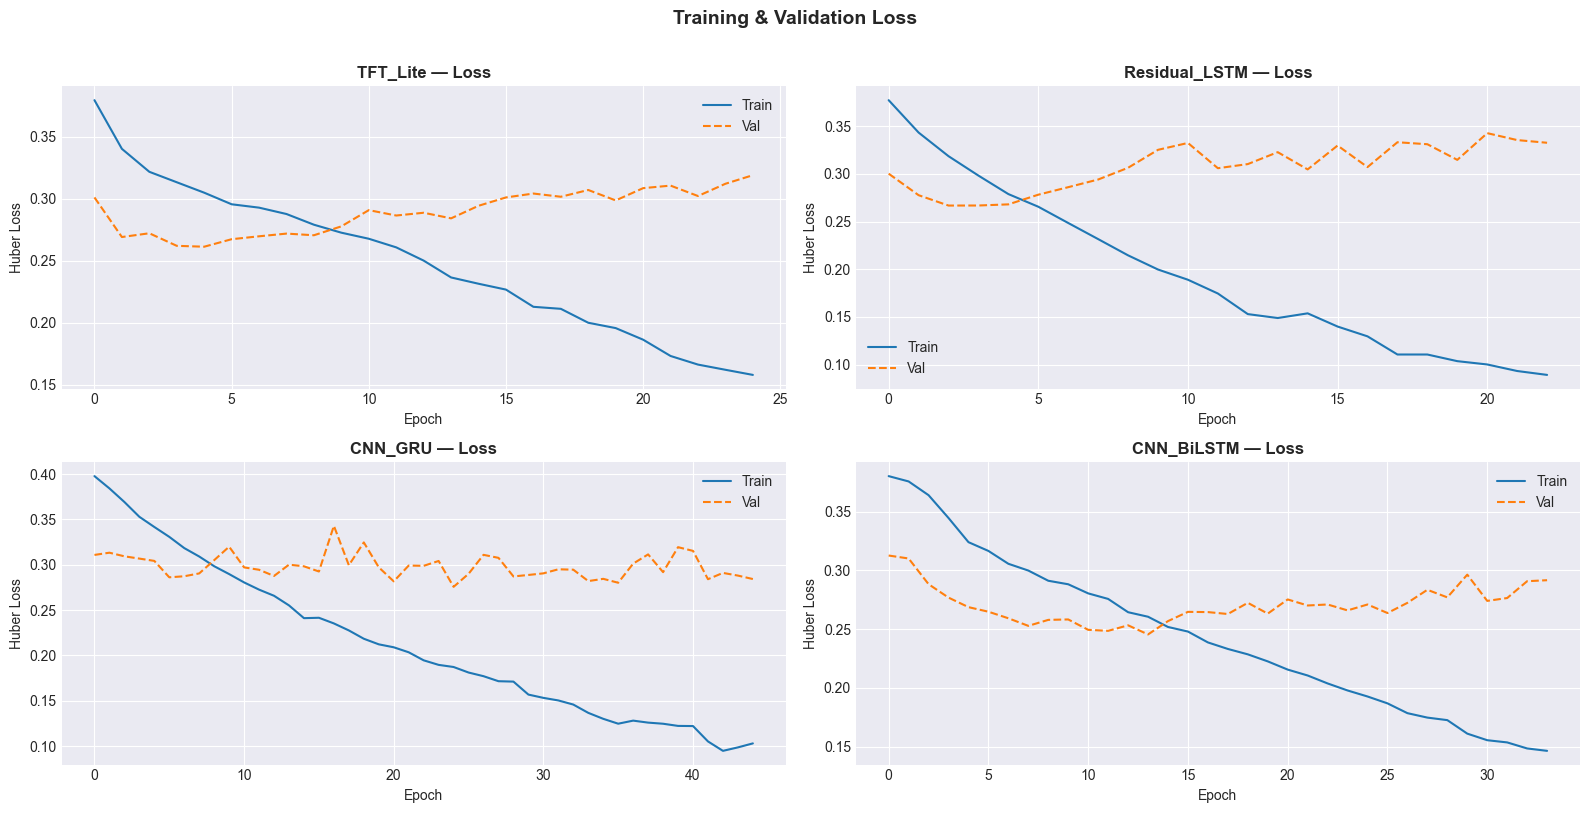

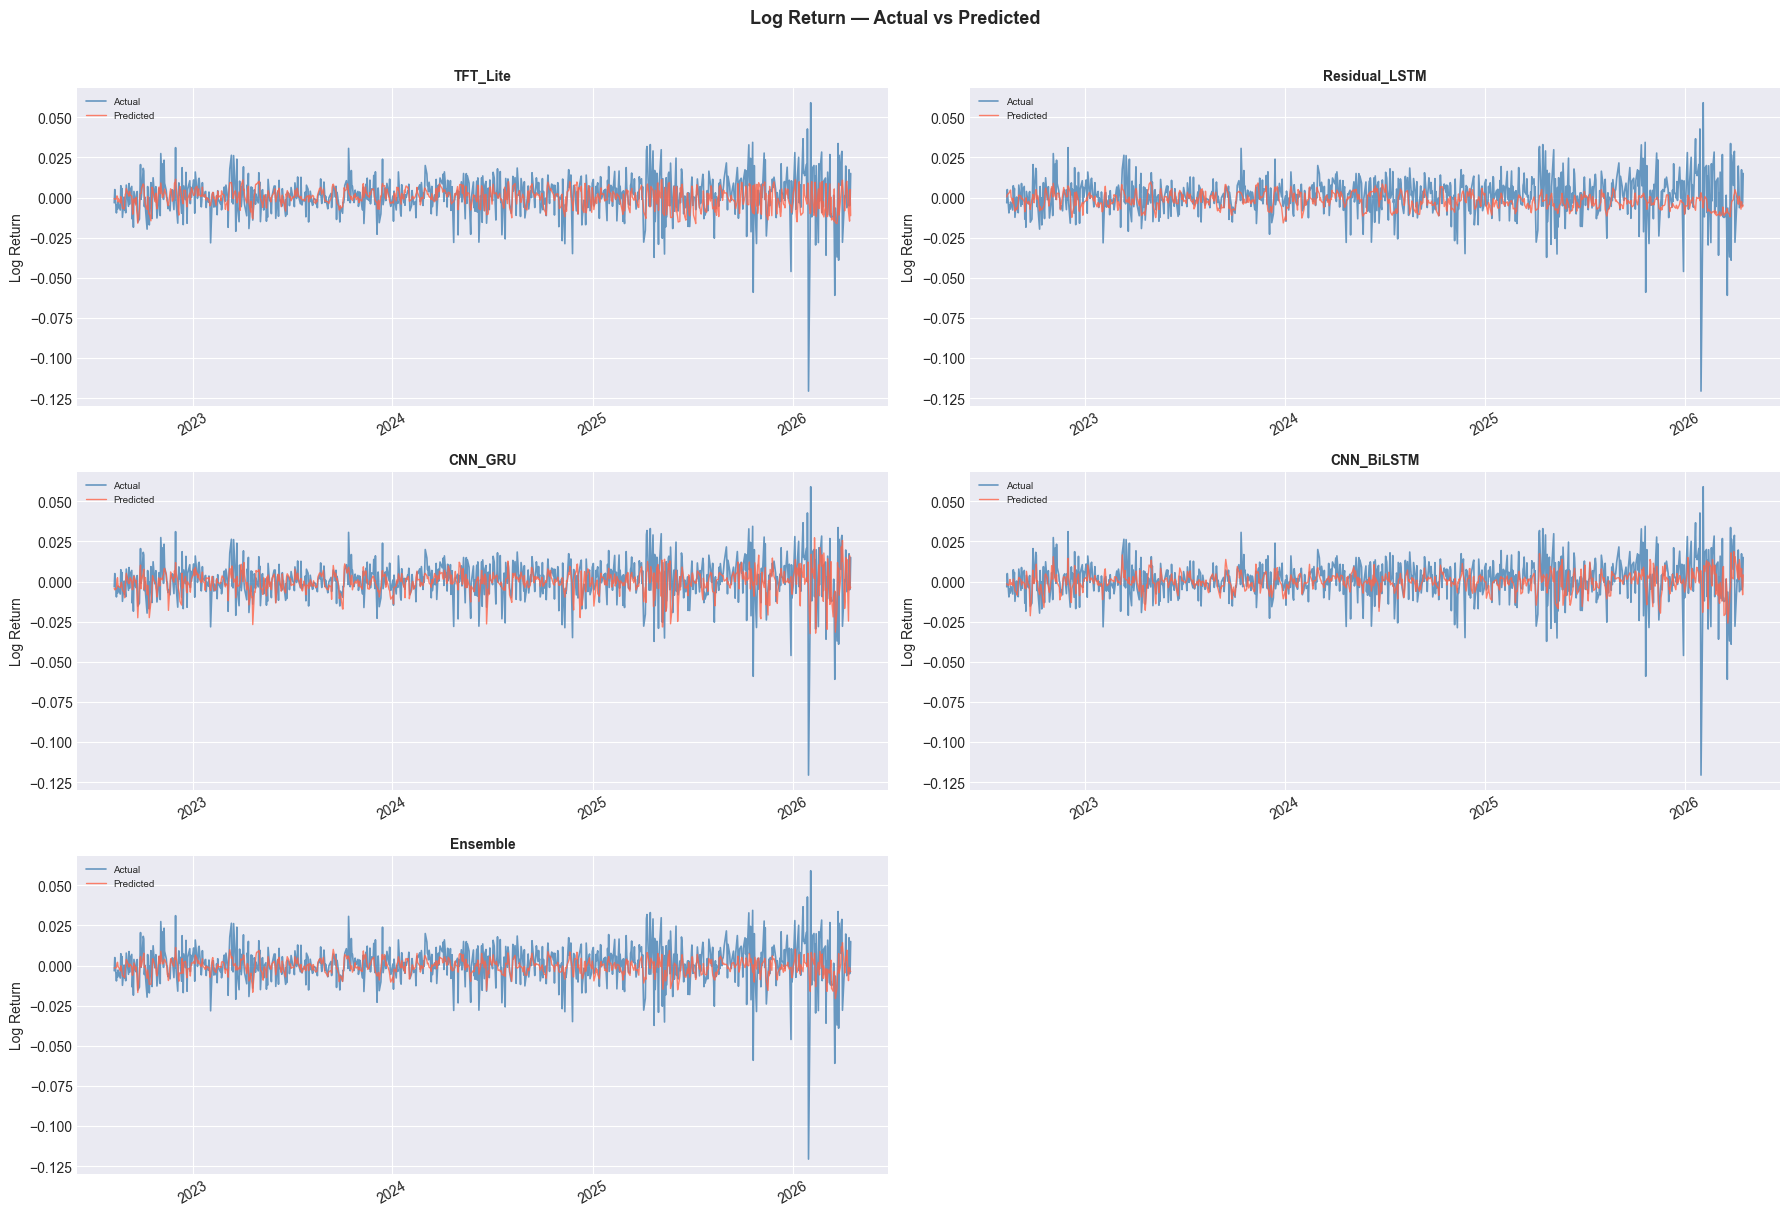

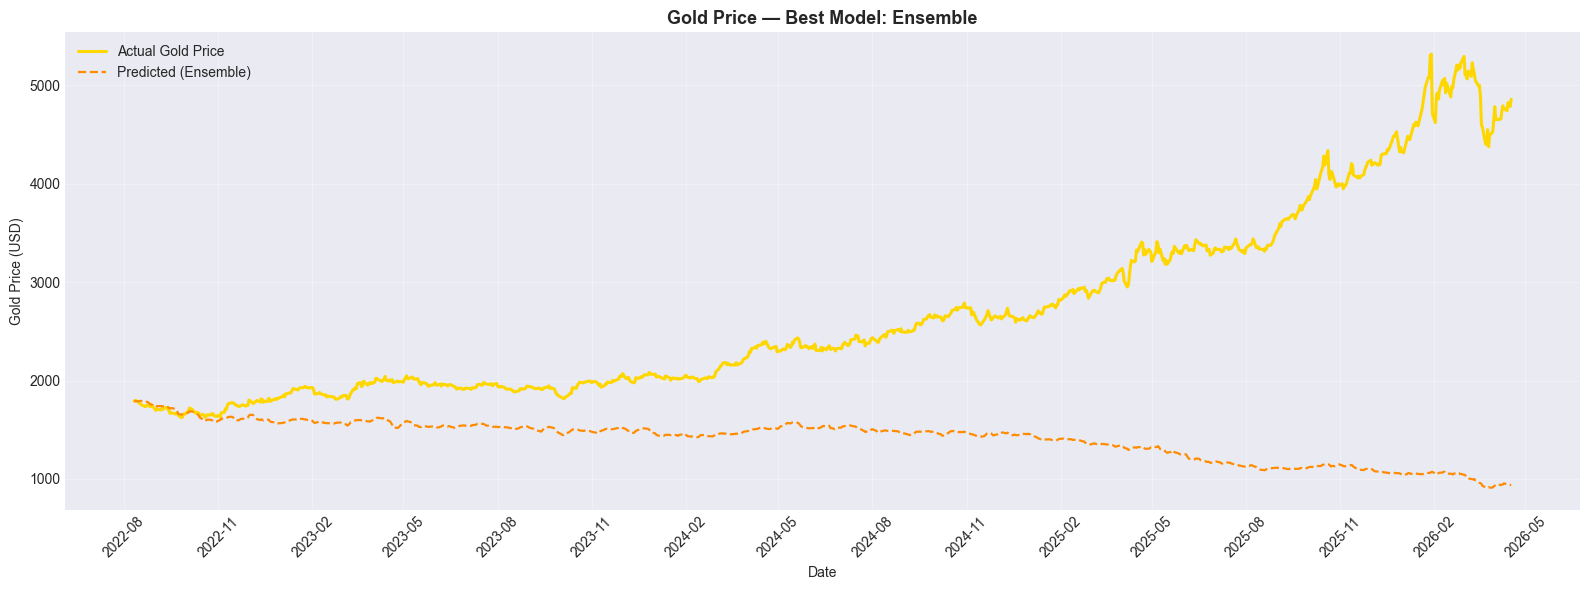

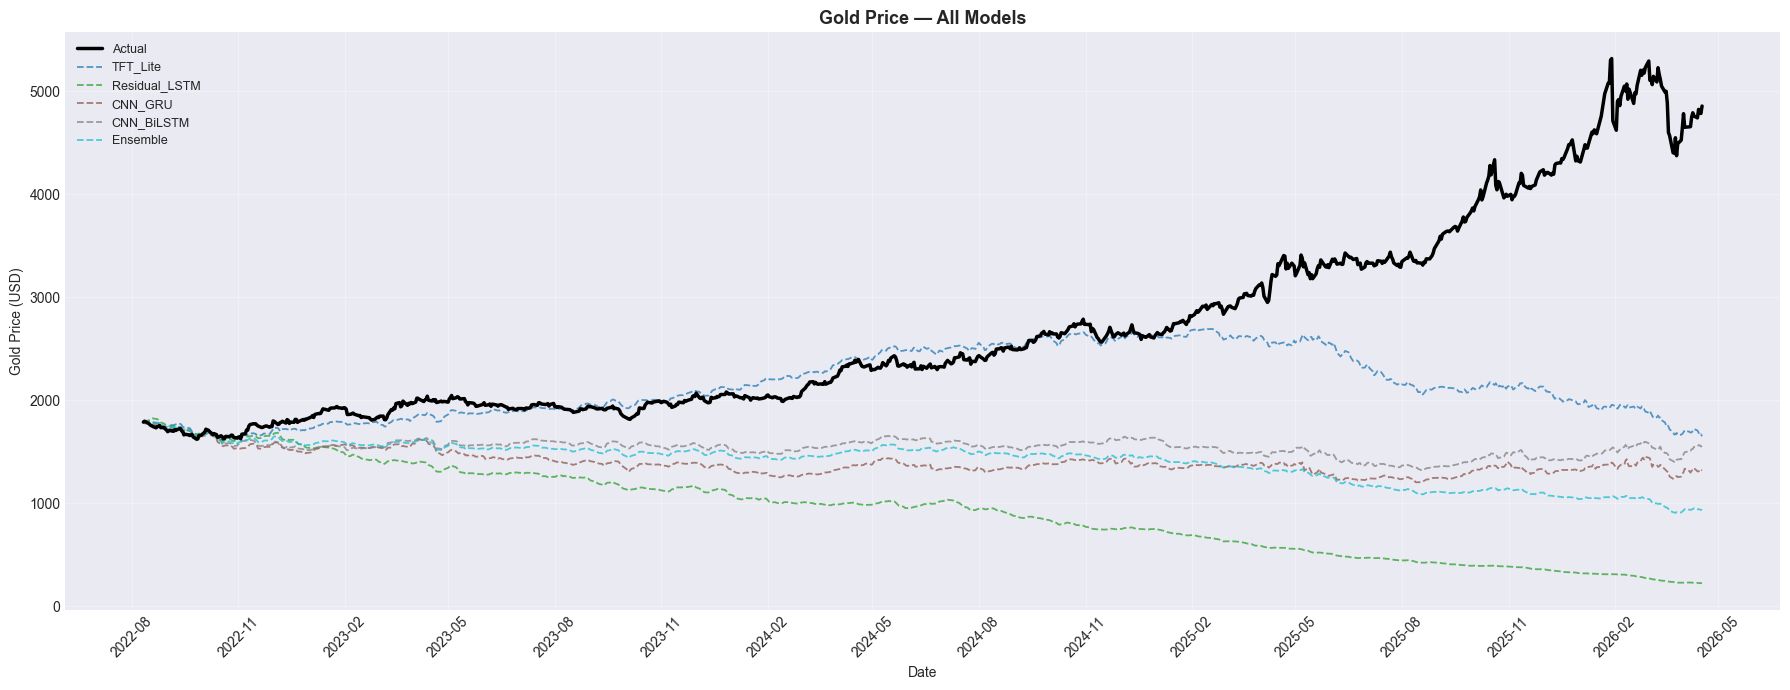

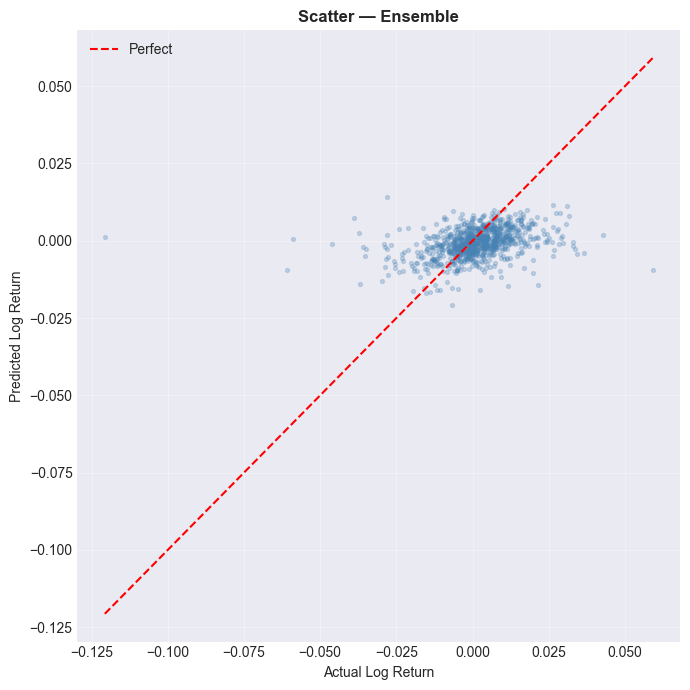

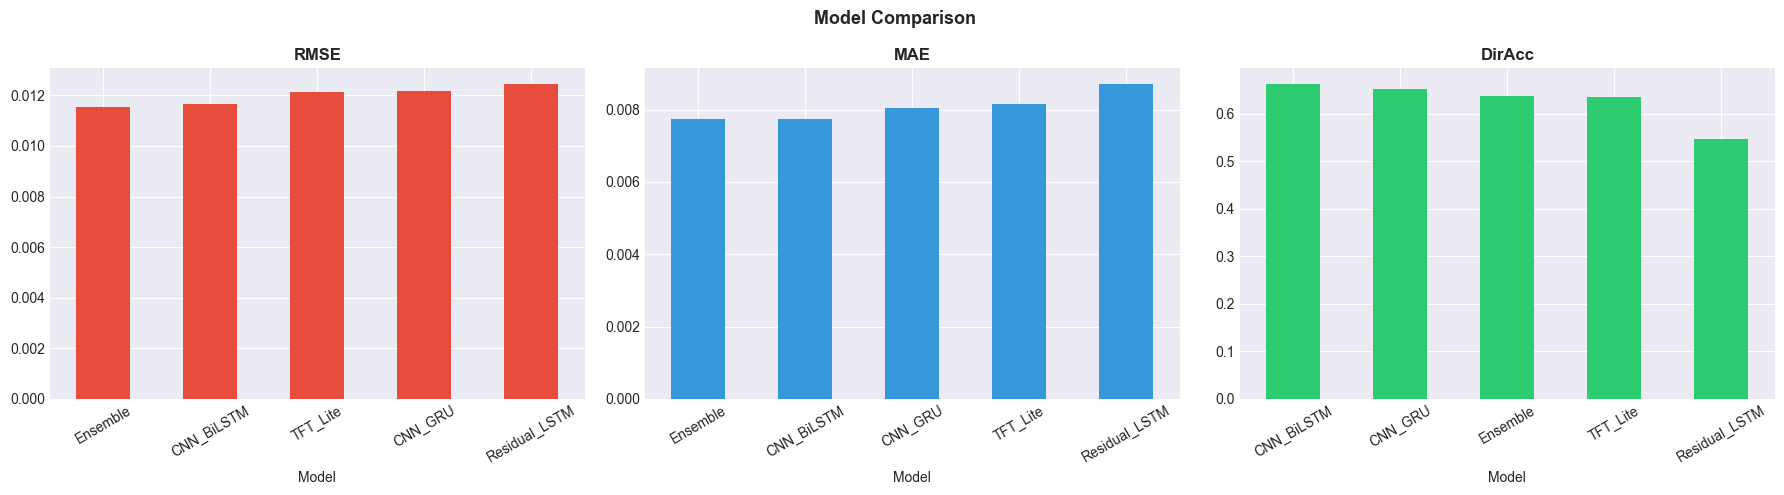

In [13]:



# ============================================================
# 19. PLOTS
# ============================================================
plt.style.use('seaborn-v0_8-darkgrid')

# ── Fig 1: Training Curves ───────────────────────────────────
n_m  = len(trained_models)
cols = 2
rows = (n_m + 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()
for idx, (name, hist) in enumerate(histories.items()):
    ax = axes[idx]
    ax.plot(hist.history['loss'],     label='Train', lw=1.5)
    ax.plot(hist.history['val_loss'], label='Val',
            lw=1.5, linestyle='--')
    ax.set_title(f'{name} — Loss', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Huber Loss')
    ax.legend()
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Training & Validation Loss',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('01_training_curves.png', dpi=150,
            bbox_inches='tight')
plt.show()

# ── Fig 2: Log Return Grid ───────────────────────────────────
n_res = len(results)
cols  = 2
rows  = (n_res + 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
axes = axes.flatten()
for idx, (name, r) in enumerate(results.items()):
    ax = axes[idx]
    ax.plot(test_dates, r['actuals'],
            label='Actual',    color='steelblue', lw=1.2, alpha=0.8)
    ax.plot(test_dates, r['preds'],
            label='Predicted', color='tomato',    lw=1.0, alpha=0.8)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_ylabel('Log Return')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=7)
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Log Return — Actual vs Predicted',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_log_return_all.png', dpi=150,
            bbox_inches='tight')
plt.show()

# ── Fig 3: Price — Best Model ────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(test_dates, actual_prices,
        label='Actual Gold Price', color='gold', lw=2.2)
ax.plot(test_dates, pred_prices[best_name],
        label=f'Predicted ({best_name})',
        color='darkorange', lw=1.6, linestyle='--')
ax.set_title(f'Gold Price — Best Model: {best_name}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Gold Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('03_price_best.png', dpi=150)
plt.show()

# ── Fig 4: All Models Price ──────────────────────────────────
cmap = plt.cm.get_cmap('tab10', len(results))
fig, ax = plt.subplots(figsize=(18, 7))
ax.plot(test_dates, actual_prices,
        label='Actual', color='black', lw=2.5, zorder=10)
for i, (name, pp) in enumerate(pred_prices.items()):
    ax.plot(test_dates, pp, label=name,
            color=cmap(i), lw=1.3, alpha=0.75, linestyle='--')
ax.set_title('Gold Price — All Models',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Gold Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('04_price_all.png', dpi=150)
plt.show()

# ── Fig 5: Scatter — Best Model ──────────────────────────────
bp = results[best_name]['preds']
ba = results[best_name]['actuals']
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(ba, bp, alpha=0.25, s=8, color='steelblue')
lims = [min(ba.min(), bp.min()), max(ba.max(), bp.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect')
ax.set_xlabel('Actual Log Return')
ax.set_ylabel('Predicted Log Return')
ax.set_title(f'Scatter — {best_name}', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('05_scatter.png', dpi=150)
plt.show()

# ── Fig 6: Model Comparison ──────────────────────────────────
comp = perf_df.copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['RMSE', 'MAE', 'DirAcc']
colors  = ['#e74c3c', '#3498db', '#2ecc71']
for ax, met, col in zip(axes, metrics, colors):
    asc = (met != 'DirAcc')
    comp.sort_values(met, ascending=asc).plot.bar(
        x='Model', y=met, ax=ax, color=col, legend=False)
    ax.set_title(f'{met}', fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Model Comparison', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.savefig('06_comparison.png', dpi=150,
            bbox_inches='tight')
plt.show()



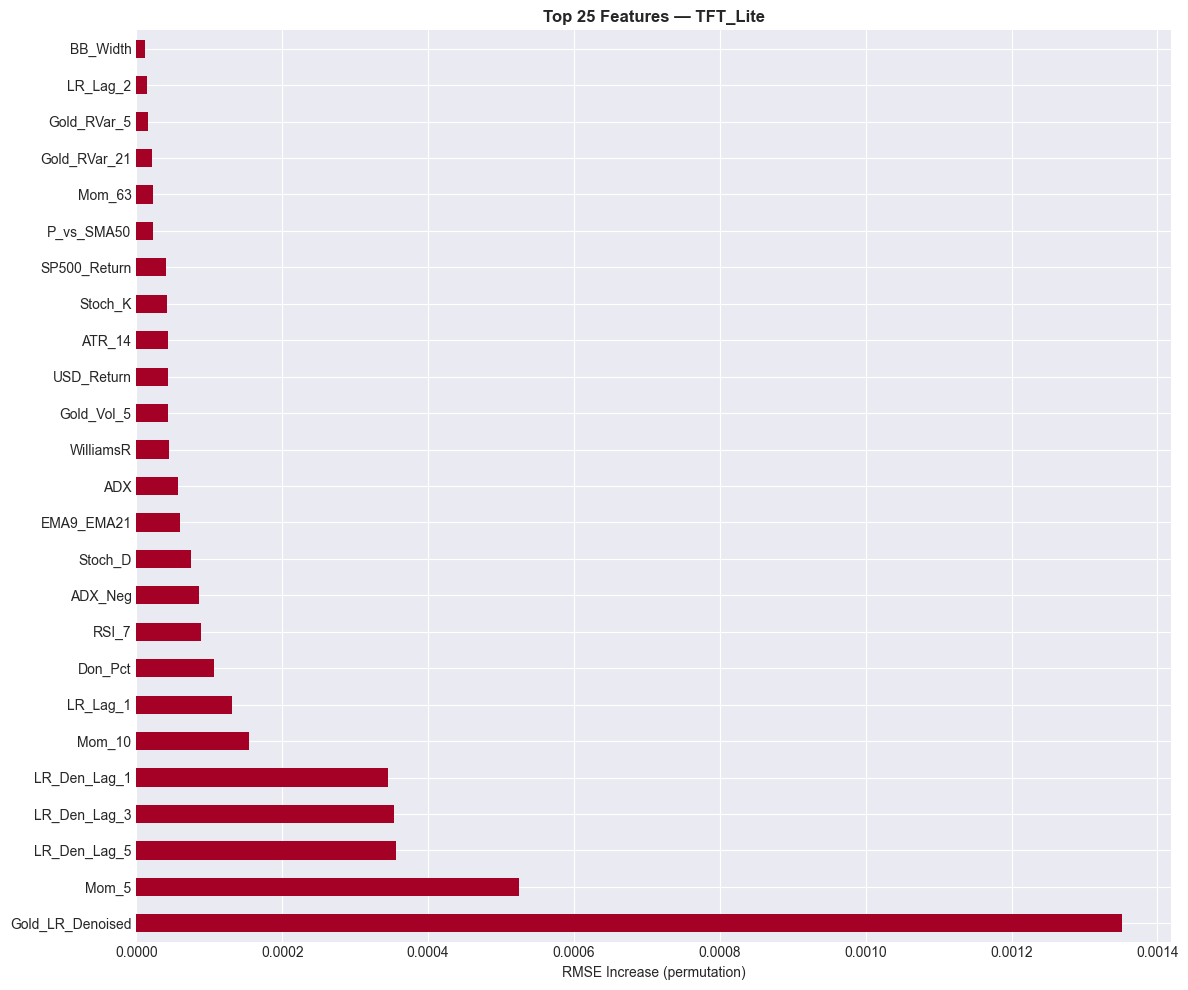

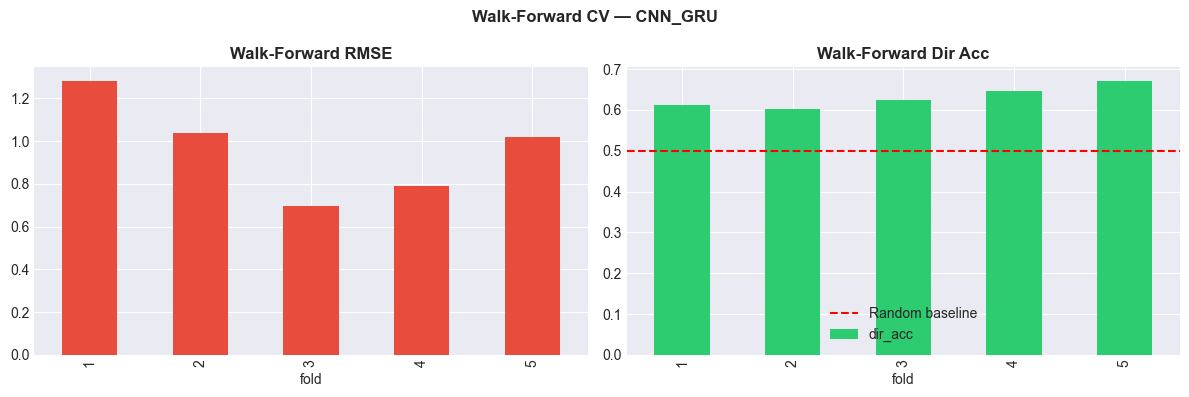


  Pipeline complete.
   Best     : TFT_Lite
   RMSE     : 0.011385
   Dir Acc  : 65.19%


In [28]:
# ── Fig 7: Feature Importance ────────────────────────────────
#best_model    = trained_models.get(best_name)
best_name = perf_df[perf_df['Model'] != 'Ensemble'].iloc[0]['Model']
#best_model = trained_models[best_name]
best_model = trained_models[best_name]
baseline_rmse = results[best_name]['RMSE']
importance    = {}

for i, feat in enumerate(top_features):
    X_p = X_test.copy()
    X_p[:, :, i] = np.random.permutation(
        X_p[:, :, i].flatten()).reshape(X_p[:, :, i].shape)
    pp = scaler_y.inverse_transform(
        best_model.predict(X_p, verbose=0)).flatten()
    importance[feat] = (np.sqrt(mean_squared_error(
                            actuals_inv, pp)) - baseline_rmse)

imp_s = pd.Series(importance).sort_values(ascending=False)
plt.figure(figsize=(12, max(6, len(imp_s) // 4)))
imp_s.head(25).plot.barh(colormap='RdYlGn')
plt.xlabel('RMSE Increase (permutation)')
plt.title(f'Top 25 Features — {best_name}',
          fontweight='bold')
plt.tight_layout()
plt.savefig('07_feature_importance.png', dpi=150)
plt.show()

# ── Fig 8: Walk-Forward ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
wf_df.plot.bar(x='fold', y='rmse',    ax=axes[0],
               legend=False, color='#e74c3c')
axes[0].set_title('Walk-Forward RMSE', fontweight='bold')
wf_df.plot.bar(x='fold', y='dir_acc', ax=axes[1],
               legend=False, color='#2ecc71')
axes[1].axhline(0.5, color='red', linestyle='--',
                label='Random baseline')
axes[1].set_title('Walk-Forward Dir Acc', fontweight='bold')
axes[1].legend()
plt.suptitle('Walk-Forward CV — CNN_GRU', fontweight='bold')
plt.tight_layout()
plt.savefig('08_walk_forward.png', dpi=150)
plt.show()

print("\n  Pipeline complete.")
print(f"   Best     : {best_name}")
print(f"   RMSE     : {results[best_name]['RMSE']:.6f}")
print(f"   Dir Acc  : {results[best_name]['DirAcc']:.2%}")

